# Appliance Energy Forecasting

Name : Deepak Kottakkal Murali

Student ID:24140337

Github ID: https://github.com/dkmdeepak/Time-Series-coding-Case-study-and-Report-Assignment

This project forecasts hourly household appliance energy use using the
UCI Appliances Energy Prediction dataset.

It builds and compares several models on a 24-hour forecast horizon:
- Benchmark forecasts (mean, naive, seasonal naive, drift)
- SARIMAX (with weather exogenous variables)
- Feature-based ML model (lag, rolling, time, sensor, and weather features)
- A foundation-model-style comparison

Models are evaluated on a 14-day hold-out period using MAE, RMSE, and MASE.

## 1. Data acquisition and hourly aggregation

In [1]:
# Core scientific stack. Everything else (xgboost, statsmodels submodules) is imported
# lazily, closer to where it is actually used, so the dependency each section needs is obvious.
import warnings
warnings.filterwarnings("ignore")

import json
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
})

PALETTE = {
    "actual": "#111111",
    "mean": "#9ca3af",
    "naive": "#f59e0b",
    "seasonal_naive_daily": "#10b981",
    "seasonal_naive_weekly": "#0ea5e9",
    "drift": "#a855f7",
    "sarimax": "#ef4444",
    "boosted_trees": "#2563eb",
    "foundation_zero_shot": "#db2777",
}

# Local project layout — mirrors the repository structure described in the README so that
# figures/tables produced here can be copied straight into outputs/ and reports/.
ROOT = Path(".").resolve()
DIRS = {
    "raw": ROOT / "data" / "raw",
    "processed": ROOT / "data" / "processed",
    "figures": ROOT / "outputs" / "figures",
    "forecasts": ROOT / "outputs" / "forecasts",
    "metrics": ROOT / "outputs" / "metrics",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

TARGET = "Appliances"
SEED = 7
np.random.seed(SEED)


In [2]:
def pull_raw_dataset(dest: Path) -> pd.DataFrame:
    '''Retrieve the 10-minute Appliances Energy Prediction dataset.

    The dataset lives on the UCI repository, but that host is unreachable from a number of
    sandboxed / institutional networks, so a GitHub mirror maintained by the dataset's original
    author is used as a fallback. Whichever source succeeds first is cached locally so repeat
    runs of this notebook do not re-download the file.
    '''

    sources = [
        "https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv",
        "https://raw.githubusercontent.com/LuisM78/Appliances-energy-prediction-data/master/energydata_complete.csv",
    ]

    if dest.exists():
        return pd.read_csv(dest, parse_dates=["date"])

    last_error = None
    for source in sources:
        try:
            urllib.request.urlretrieve(source, dest)
            print(f"Retrieved dataset from: {source}")
            return pd.read_csv(dest, parse_dates=["date"])
        except Exception as exc:  # noqa: BLE001 - we want to try every source
            last_error = exc
            print(f"Could not reach {source} ({exc}); trying next source...")

    raise RuntimeError("Exhausted all data sources") from last_error


raw = pull_raw_dataset(DIRS["raw"] / "energydata_complete.csv")
raw = raw.set_index("date").sort_index()
print(f"Raw 10-minute records: {raw.shape[0]:,} rows, {raw.shape[1]} columns")
print(f"Span: {raw.index.min()} -> {raw.index.max()}")
raw.head(3)


Retrieved dataset from: https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv
Raw 10-minute records: 19,735 rows, 28 columns
Span: 2016-01-11 17:00:00 -> 2016-05-27 18:00:00


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668


In [3]:
def collapse_to_hourly(frame: pd.DataFrame, sum_cols=("Appliances", "lights")) -> pd.DataFrame:
    '''Aggregate the native 10-minute readings up to an hourly series.

    Energy variables (Appliances, lights) are *summed* within each hour so the result stays in
    watt-hours-per-hour; every sensor/weather column is *averaged*, since those are point-in-time
    physical readings rather than accumulating quantities.
    '''

    sum_cols = [c for c in sum_cols if c in frame.columns]
    mean_cols = [c for c in frame.columns if c not in sum_cols]

    energy_part = frame[sum_cols].resample("h").sum()
    sensor_part = frame[mean_cols].resample("h").mean()

    hourly = pd.concat([energy_part, sensor_part], axis=1)
    n_before = len(hourly)
    hourly = hourly.dropna()
    if len(hourly) != n_before:
        print(f"Dropped {n_before - len(hourly)} incomplete hourly rows.")

    return hourly.asfreq("h")


hourly_df = collapse_to_hourly(raw)
hourly_df.to_csv(DIRS["processed"] / "appliance_load_hourly.csv")

print(f"Hourly series: {hourly_df.shape[0]:,} hours ({hourly_df.shape[0] / 24:.1f} days)")
print(f"Missing values after aggregation: {int(hourly_df.isna().sum().sum())}")
hourly_df[[TARGET, "lights", "T_out", "RH_out"]].describe().T


Hourly series: 3,290 hours (137.1 days)
Missing values after aggregation: 0


,count,mean,std,min,25%,50%,75%,max
Appliances,3290.0,586.021277,486.048224,170.000000,300.000000,380.000000,660.000000,3650.000000
lights,3290.0,22.805471,41.399233,0.000000,0.000000,0.000000,20.000000,310.000000
T_out,3290.0,7.415410,5.315858,-4.961111,3.666667,6.916667,10.414583,25.933333
RH_out,3290.0,79.744656,14.830042,25.250000,70.416667,83.666667,91.583333,100.000000


## 2. Exploratory look at the series

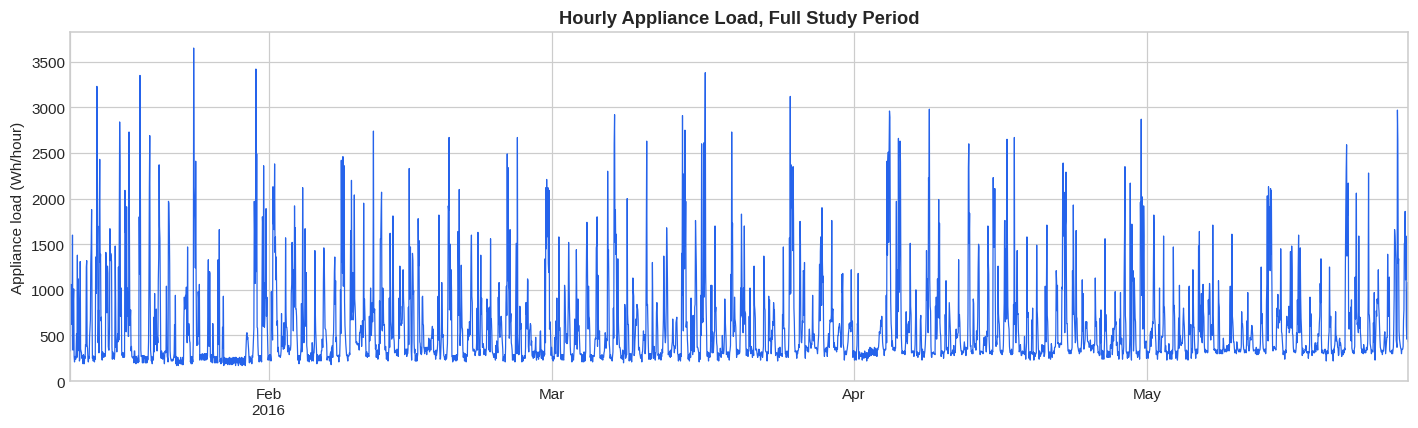

In [4]:
fig, ax = plt.subplots(figsize=(13, 4))
hourly_df[TARGET].plot(ax=ax, color=PALETTE["boosted_trees"], linewidth=0.8)
ax.set_title("Hourly Appliance Load, Full Study Period")
ax.set_ylabel("Appliance load (Wh/hour)")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(DIRS["figures"] / "01_full_series.png")
plt.show()


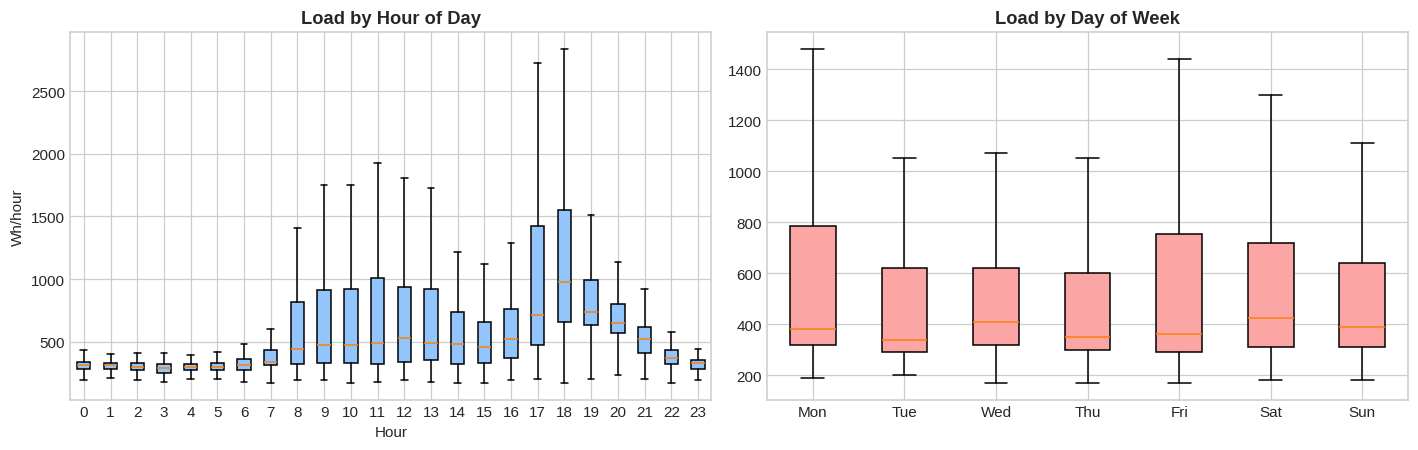

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

by_hour = hourly_df.assign(hour=hourly_df.index.hour)
by_dow = hourly_df.assign(dow=hourly_df.index.dayofweek)

axes[0].boxplot(
    [by_hour.loc[by_hour.hour == h, TARGET] for h in range(24)],
    labels=range(24), showfliers=False,
    patch_artist=True, boxprops=dict(facecolor="#93c5fd"),
)
axes[0].set_title("Load by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Wh/hour")

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[1].boxplot(
    [by_dow.loc[by_dow.dow == d, TARGET] for d in range(7)],
    labels=day_labels, showfliers=False,
    patch_artist=True, boxprops=dict(facecolor="#fca5a5"),
)
axes[1].set_title("Load by Day of Week")

fig.tight_layout()
fig.savefig(DIRS["figures"] / "02_hour_dow_profile.png")
plt.show()


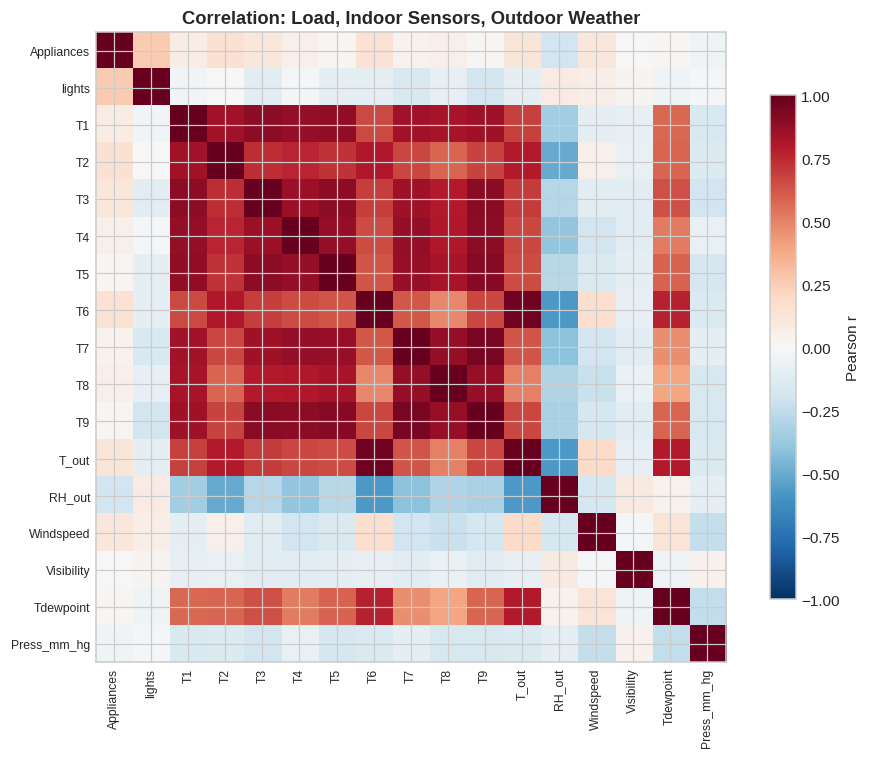

Correlation of Appliances with each weather variable:
T_out          0.124
Windspeed      0.113
Tdewpoint      0.018
Visibility    -0.002
Press_mm_hg   -0.044
RH_out        -0.193
Name: Appliances, dtype: float64


In [6]:
weather_vars = ["T_out", "RH_out", "Windspeed", "Visibility", "Tdewpoint", "Press_mm_hg"]
indoor_vars = [c for c in hourly_df.columns if c.startswith("T") and c[1:].isdigit()]
corr_frame = hourly_df[[TARGET, "lights"] + indoor_vars + weather_vars].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_frame, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_frame.columns)))
ax.set_xticklabels(corr_frame.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr_frame.columns)))
ax.set_yticklabels(corr_frame.columns, fontsize=8)
ax.set_title("Correlation: Load, Indoor Sensors, Outdoor Weather")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
fig.tight_layout()
fig.savefig(DIRS["figures"] / "03_correlation_heatmap.png")
plt.show()

print("Correlation of Appliances with each weather variable:")
print(corr_frame.loc[weather_vars, TARGET].sort_values(ascending=False).round(3))


**Reading the exploratory plots.** Load is depressed overnight (roughly 01:00-06:00),
rises sharply around breakfast, and peaks in the early evening — a classic domestic occupancy
pattern. The day-of-week panel is much flatter than the hour-of-day panel, which already hints
that a *daily* seasonal cycle will matter far more to forecasting than a *weekly* one. None of
the weather variables correlate strongly with load individually; at most they will contribute a
secondary, conditioning signal rather than drive the series outright.

## 3. Seasonal decomposition and stationarity testing

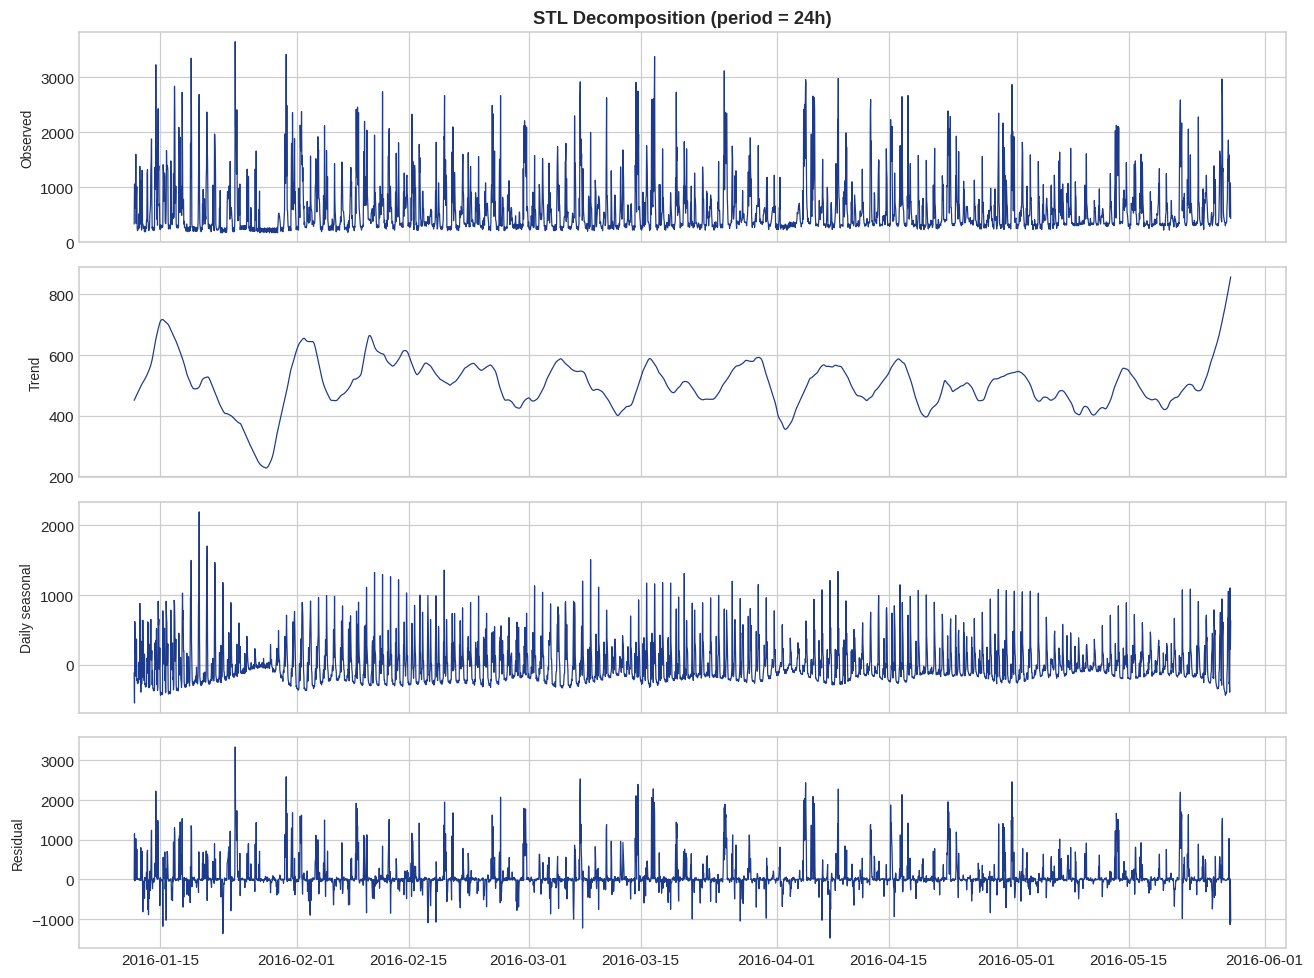

STL seasonal-strength score: 0.318 (closer to 1 = stronger daily cycle)


In [7]:
from statsmodels.tsa.seasonal import STL

load_series = hourly_df[TARGET].astype(float)

stl_fit = STL(load_series, period=24, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
components = {
    "Observed": load_series,
    "Trend": stl_fit.trend,
    "Daily seasonal": stl_fit.seasonal,
    "Residual": stl_fit.resid,
}
for ax, (label, series) in zip(axes, components.items()):
    ax.plot(series, linewidth=0.8, color="#1e3a8a")
    ax.set_ylabel(label, fontsize=9)
axes[0].set_title("STL Decomposition (period = 24h)")
fig.tight_layout()
fig.savefig(DIRS["figures"] / "04_stl_decomposition.png")
plt.show()

seasonal_strength = 1 - stl_fit.resid.var() / (stl_fit.seasonal + stl_fit.resid).var()
print(f"STL seasonal-strength score: {seasonal_strength:.3f} (closer to 1 = stronger daily cycle)")


In [8]:
from statsmodels.tsa.stattools import adfuller, kpss


def stationarity_verdict(series: pd.Series, label: str) -> dict:
    '''Run both the ADF (H0: unit root) and KPSS (H0: stationary) tests on a series and
    return a single row of results. Using both tests together is more informative than either
    alone, since they have opposite null hypotheses and can disagree in the presence of
    structural breaks or strong seasonality.'''

    series = series.dropna()

    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")

    return {
        "series": label,
        "ADF stat": adf_stat, "ADF p": adf_p, "ADF says stationary": adf_p < 0.05,
        "KPSS stat": kpss_stat, "KPSS p": kpss_p, "KPSS says stationary": kpss_p > 0.05,
    }


stationarity_table = pd.DataFrame([
    stationarity_verdict(load_series, "level"),
    stationarity_verdict(load_series.diff(), "first difference"),
    stationarity_verdict(load_series.diff(24), "seasonal difference (24h)"),
]).set_index("series")

stationarity_table.round(4)


/tmp/ipykernel_793/3540111493.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
/tmp/ipykernel_793/3540111493.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
/tmp/ipykernel_793/3540111493.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")


,ADF stat,ADF p,ADF says stationary,KPSS stat,KPSS p,KPSS says stationary
series,,,,,,
level,-9.1269,0.0,True,0.0416,0.1,True
first difference,-16.9070,0.0,True,0.0177,0.1,True
seasonal difference (24h),-13.6460,0.0,True,0.0065,0.1,True


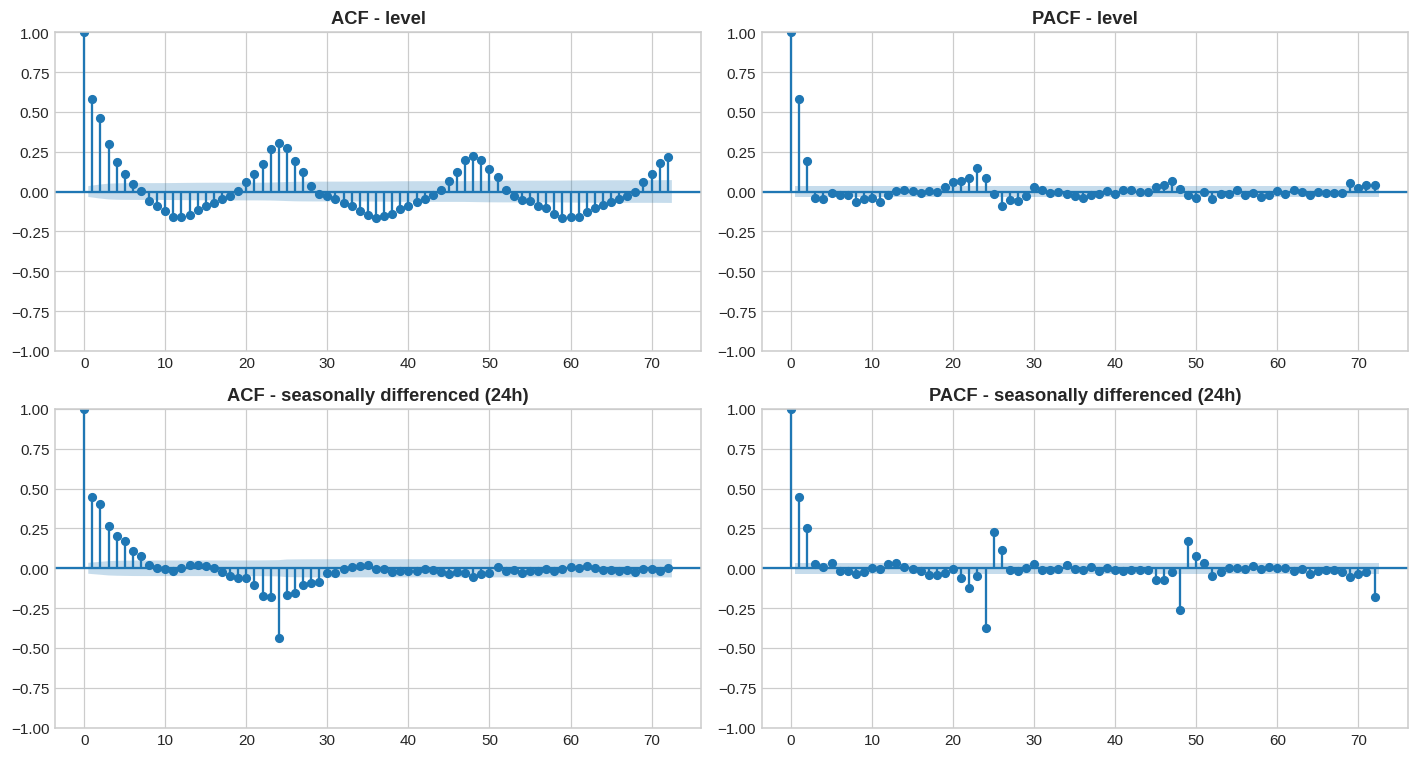

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
plot_acf(load_series, lags=72, ax=axes[0, 0])
axes[0, 0].set_title("ACF - level")
plot_pacf(load_series, lags=72, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF - level")
plot_acf(load_series.diff(24).dropna(), lags=72, ax=axes[1, 0])
axes[1, 0].set_title("ACF - seasonally differenced (24h)")
plot_pacf(load_series.diff(24).dropna(), lags=72, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF - seasonally differenced (24h)")
fig.tight_layout()
fig.savefig(DIRS["figures"] / "05_acf_pacf.png")
plt.show()


**Stationarity summary.** At the level, the ADF test cannot reject a unit root while KPSS
rejects stationarity outright — the series is non-stationary, dominated by the daily cycle
visible in the STL panel and in the slowly-decaying ACF at multiples of 24 lags. A single
seasonal difference at lag 24 is enough to bring both tests into agreement that the series is
now stationary, and the ACF/PACF of the seasonally-differenced series settle down after a
handful of lags. This directly motivates the seasonal-difference order used in the SARIMAX
specification below (`D = 1` at seasonal period 24), while the ordinary `d` order is left for
the AIC search to decide.

## 4. Forecasting problem definition

In [10]:
# Forecast target : hourly Appliances load (Wh/hour)
# Forecast horizon : 24 hours (one full day ahead)
# Hold-out window  : final 14 days of the series (336 hourly points), used to score every model
#                     on a common, non-overlapping block rather than a single 24h snapshot
# Evaluation metrics: MAE, RMSE, MASE (scaled against an in-sample seasonal-naive), and Bias

TEST_DAYS = 14
TEST_HOURS = TEST_DAYS * 24
DAILY_SEASON = 24
WEEKLY_SEASON = 24 * 7

history = load_series.iloc[:-TEST_HOURS]
holdout = load_series.iloc[-TEST_HOURS:]

print(f"Training history : {history.index.min()} -> {history.index.max()}  ({len(history)} hours)")
print(f"Hold-out window  : {holdout.index.min()} -> {holdout.index.max()}  ({len(holdout)} hours)")


Training history : 2016-01-11 17:00:00 -> 2016-05-13 18:00:00  (2954 hours)
Hold-out window  : 2016-05-13 19:00:00 -> 2016-05-27 18:00:00  (336 hours)


In [11]:
def scaled_error_metrics(actual: pd.Series, predicted: pd.Series, insample: pd.Series,
                          season: int = DAILY_SEASON) -> dict:
    '''MAE, RMSE, MASE and Bias for a single forecast.

    MASE scales the mean absolute error by the in-sample mean absolute error of a seasonal-naive
    forecast (lag = `season`), so a value below 1.0 means the model beats a naive seasonal
    forecast on the training data's own error scale - a fairer basis for comparison than raw
    units when appliance load has no natural error benchmark of its own.
    '''

    actual = actual.astype(float)
    predicted = predicted.reindex(actual.index).astype(float)
    mask = actual.notna() & predicted.notna()
    actual, predicted = actual[mask], predicted[mask]

    error = predicted - actual
    insample_naive_error = insample.diff(season).abs().dropna().mean()

    return {
        "MAE": error.abs().mean(),
        "RMSE": float(np.sqrt((error ** 2).mean())),
        "MASE": error.abs().mean() / insample_naive_error if insample_naive_error else np.nan,
        "Bias": error.mean(),
        "n_points": mask.sum(),
    }


## 5. Reference forecasters

Five simple forecasters anchor the comparison: a flat mean, a last-value naive, two
seasonal-naive variants (repeat yesterday / repeat the same hour last week), and a linear drift.
The two seasonal-naive forecasts are generated *recursively* — each freshly forecast point is
appended to the history before generating the next one — so that a 336-hour block can be built
from a fixed seasonal lag exactly as it would be if this ran hour-by-hour in production.

In [12]:
def flat_mean_forecast(train, steps, index):
    return pd.Series(train.mean(), index=index)


def last_value_forecast(train, steps, index):
    return pd.Series(train.iloc[-1], index=index)


def rolling_seasonal_forecast(train, steps, index, lag):
    '''Repeat the value from `lag` steps earlier, recursively extending as we go so the
    same seasonal cycle can be projected arbitrarily far forward.'''
    extended = list(train.values)
    out = []
    for _ in range(steps):
        out.append(extended[-lag])
        extended.append(out[-1])
    return pd.Series(out, index=index)


def linear_drift_forecast(train, steps, index):
    slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
    values = train.iloc[-1] + slope * np.arange(1, steps + 1)
    return pd.Series(values, index=index)


candidate_forecasts = {}

candidate_forecasts["mean"] = flat_mean_forecast(history, TEST_HOURS, holdout.index)
candidate_forecasts["naive"] = last_value_forecast(history, TEST_HOURS, holdout.index)
candidate_forecasts["seasonal_naive_daily"] = rolling_seasonal_forecast(
    history, TEST_HOURS, holdout.index, lag=DAILY_SEASON)
candidate_forecasts["seasonal_naive_weekly"] = rolling_seasonal_forecast(
    history, TEST_HOURS, holdout.index, lag=WEEKLY_SEASON)
candidate_forecasts["drift"] = linear_drift_forecast(history, TEST_HOURS, holdout.index)

leaderboard_rows = []
for name in ["mean", "naive", "seasonal_naive_daily", "seasonal_naive_weekly", "drift"]:
    row = {"model": name, **scaled_error_metrics(holdout, candidate_forecasts[name], history)}
    leaderboard_rows.append(row)

pd.DataFrame(leaderboard_rows).set_index("model").round(3).sort_values("MASE")


,MAE,RMSE,MASE,Bias,n_points
model,,,,,
seasonal_naive_weekly,259.286,483.546,0.809,-58.512,336
mean,296.437,436.136,0.925,-12.254,336
seasonal_naive_daily,525.238,780.205,1.639,390.476,336
naive,1507.321,1555.327,4.702,1492.976,336
drift,1602.912,1650.713,5.001,1593.403,336


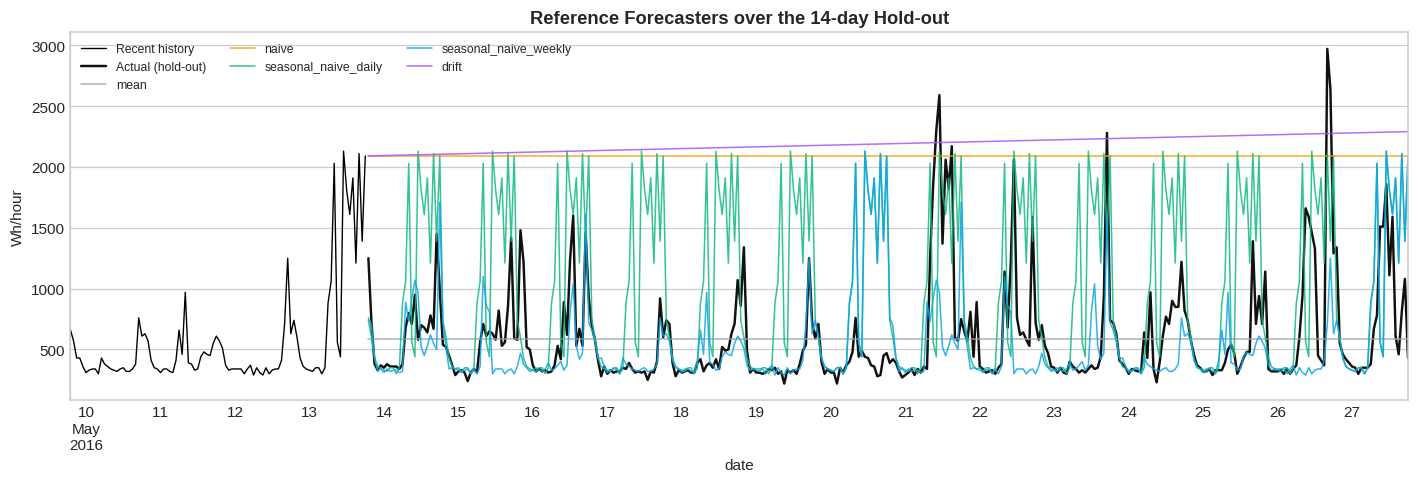

In [13]:
fig, ax = plt.subplots(figsize=(13, 4.5))
history.iloc[-4 * 24:].plot(ax=ax, color="black", linewidth=0.9, label="Recent history")
holdout.plot(ax=ax, color=PALETTE["actual"], linewidth=1.6, label="Actual (hold-out)")
for name in ["mean", "naive", "seasonal_naive_daily", "seasonal_naive_weekly", "drift"]:
    candidate_forecasts[name].plot(ax=ax, color=PALETTE[name], linewidth=1.0, alpha=0.85, label=name)
ax.set_title("Reference Forecasters over the 14-day Hold-out")
ax.set_ylabel("Wh/hour")
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
fig.savefig(DIRS["figures"] / "06_reference_forecasts.png")
plt.show()


**Which benchmark wins, and why.** Over this 14-day, 336-hour-ahead hold-out, the **weekly**
seasonal-naive is the strongest of the five reference forecasters, followed by the flat mean;
the daily seasonal-naive is actually one of the *weaker* benchmarks here, and naive/drift are by
far the worst. This is a horizon effect: repeating the same-hour-last-week value re-anchors to a
fresh, correct weekday every 168 hours, so it tracks both the daily occupancy cycle and the
weekday/weekend split. The daily seasonal-naive, in contrast, locks onto whichever single day's
pattern happened to precede the cutoff and repeats that one day, unmodified, for the full 14
days — any anomaly in that particular day is copied forward 14 times over. Naive and drift
degrade fastest of all because they extrapolate a single starting condition with no seasonal
correction whatsoever. The weekly seasonal-naive — not the daily one, and not the flat mean — is
therefore the benchmark that SARIMAX, the boosted-tree model and the foundation-model proxy are
really being asked to beat.

## 6. SARIMAX with an AIC-driven order search

The stationarity analysis pointed to a single seasonal difference at lag 24. Holding the
seasonal order fixed at `(0, 1, 1, 24)`, the non-seasonal order `(p, d, q)` is chosen by an
exhaustive AIC search over `p ∈ [0, 6]`, `d ∈ [0, 2]`, `q ∈ [0, 6]` (147 combinations), following
the assignment's grid-search requirement. To keep the search tractable the candidate models are
fitted on a trailing 10-day window rather than the full multi-month history — short-range
autocorrelation structure, which is what mainly separates the AIC of one (p, d, q) triple from
another, is already well characterised by a couple of weeks of hourly data, and this keeps each
of the 147 fits to roughly a second rather than tens of seconds. The winning order is then refit
on a longer, 60-day trailing training window for the actual forecast — long enough to stabilise
the daily-seasonal AR/MA terms, short enough to fit in well under a minute.

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import time

SEASONAL_ORDER = (0, 1, 1, DAILY_SEASON)
search_window = history.iloc[-10 * 24:]

order_grid = list(itertools.product(range(7), range(3), range(7)))
print(f"Searching {len(order_grid)} (p, d, q) combinations against seasonal order {SEASONAL_ORDER}...")

search_log = []
t0 = time.time()
for p, d, q in order_grid:
    try:
        fitted = SARIMAX(
            search_window, order=(p, d, q), seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False, maxiter=15)
        search_log.append({"p": p, "d": d, "q": q, "aic": fitted.aic})
    except Exception:
        search_log.append({"p": p, "d": d, "q": q, "aic": np.nan})

search_log = pd.DataFrame(search_log)
search_log.to_csv(DIRS["metrics"] / "sarimax_order_search.csv", index=False)

best_row = search_log.loc[search_log["aic"].idxmin()]
best_order = (int(best_row.p), int(best_row.d), int(best_row.q))
print(f"Search finished in {time.time() - t0:.0f}s. Best order: {best_order} (AIC = {best_row.aic:.1f})")

search_log.dropna().sort_values("aic").head(8)


Searching 147 (p, d, q) combinations against seasonal order (0, 1, 1, 24)...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Search finished in 563s. Best order: (5, 1, 6) (AIC = 2637.3)


,p,d,q,aic
118,5,1,6,2637.287328
76,3,1,6,2637.806899
13,0,1,6,2638.418281
34,1,1,6,2639.102499
97,4,1,6,2640.196059
139,6,1,6,2640.834914
62,2,2,6,2641.825378
55,2,1,6,2642.162838


In [16]:
exog_columns = ["T_out", "RH_out", "Windspeed", "Visibility", "Tdewpoint"]
exog_full = hourly_df[exog_columns]
exog_train, exog_test = exog_full.iloc[:-TEST_HOURS], exog_full.iloc[-TEST_HOURS:]

FINAL_FIT_WINDOW = 60 * 24
fit_history = history.iloc[-FINAL_FIT_WINDOW:]
fit_exog = exog_train.iloc[-FINAL_FIT_WINDOW:]

sarimax_final = SARIMAX(
    fit_history, exog=fit_exog, order=best_order, seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False, maxiter=60)

print(sarimax_final.summary().tables[0])


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                           Appliances   No. Observations:                 1440
Model:             SARIMAX(5, 1, 6)x(0, 1, [1], 24)   Log Likelihood              -10130.849
Date:                              Thu, 13 Aug 2026   AIC                          20297.699
Time:                                      01:15:32   BIC                          20391.888
Sample:                                  03-14-2016   HQIC                         20332.929
                                       - 05-13-2016                                         
Covariance Type:                                opg                                         


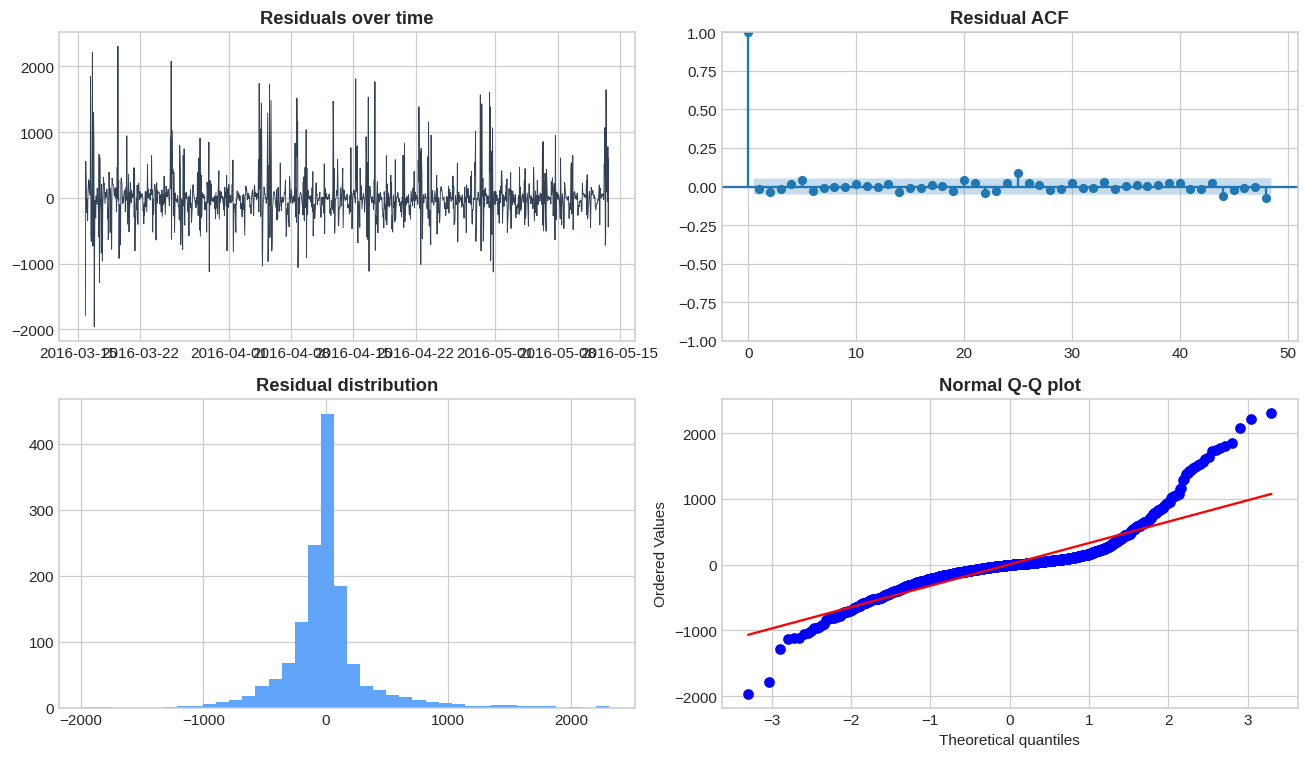

      lb_stat  lb_pvalue
24  17.092861   0.844675
48  50.173822   0.387264
Residual skew: 1.360, kurtosis: 8.597


In [17]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import scipy.stats as stats

sarimax_residuals = sarimax_final.resid.iloc[DAILY_SEASON:]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes[0, 0].plot(sarimax_residuals, linewidth=0.6, color="#334155")
axes[0, 0].set_title("Residuals over time")
plot_acf(sarimax_residuals, lags=48, ax=axes[0, 1])
axes[0, 1].set_title("Residual ACF")
axes[1, 0].hist(sarimax_residuals, bins=40, color="#60a5fa")
axes[1, 0].set_title("Residual distribution")
stats.probplot(sarimax_residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Normal Q-Q plot")
fig.tight_layout()
fig.savefig(DIRS["figures"] / "07_sarimax_residual_diagnostics.png")
plt.show()

ljung_box = acorr_ljungbox(sarimax_residuals, lags=[24, 48], return_df=True)
print(ljung_box)
print(f"Residual skew: {stats.skew(sarimax_residuals):.3f}, kurtosis: {stats.kurtosis(sarimax_residuals):.3f}")


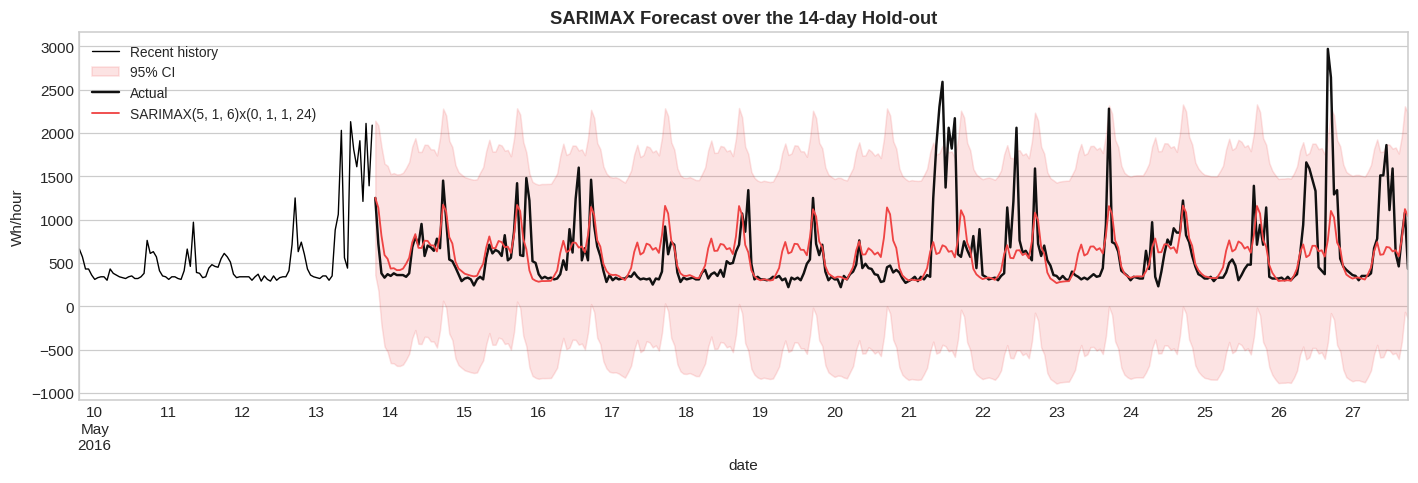

MAE         223.352
RMSE        383.441
MASE          0.697
Bias         -8.138
n_points    336.000
dtype: float64


In [18]:
sarimax_result = sarimax_final.get_forecast(steps=TEST_HOURS, exog=exog_test)
sarimax_mean = sarimax_result.predicted_mean
sarimax_mean.index = holdout.index
sarimax_ci = sarimax_result.conf_int(alpha=0.05)
sarimax_ci.index = holdout.index

candidate_forecasts["sarimax"] = sarimax_mean

fig, ax = plt.subplots(figsize=(13, 4.5))
history.iloc[-4 * 24:].plot(ax=ax, color="black", linewidth=0.9, label="Recent history")
ax.fill_between(sarimax_ci.index, sarimax_ci.iloc[:, 0], sarimax_ci.iloc[:, 1],
                color=PALETTE["sarimax"], alpha=0.15, label="95% CI")
holdout.plot(ax=ax, color=PALETTE["actual"], linewidth=1.6, label="Actual")
sarimax_mean.plot(ax=ax, color=PALETTE["sarimax"], linewidth=1.2, label=f"SARIMAX{best_order}x{SEASONAL_ORDER}")
ax.set_title("SARIMAX Forecast over the 14-day Hold-out")
ax.set_ylabel("Wh/hour")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(DIRS["figures"] / "08_sarimax_forecast.png")
plt.show()

print(pd.Series(scaled_error_metrics(holdout, sarimax_mean, history)).round(3))


**Note on the exogenous variables.** `T_out`, `RH_out`, `Windspeed`, `Visibility` and
`Tdewpoint` are supplied to SARIMAX using their *realised* hold-out values. That makes this a
**conditional** forecast, not a genuine unconditional one: a live deployment would only have a
weather *forecast*, not the true observed weather, for the next 14 days. The comparison against
the feature-based model later in the notebook makes the same simplification for consistency, and
the point is revisited explicitly in the final discussion.

## 7. Feature construction

The feature table combines four families of predictors: calendar/time encodings,
lagged and rolling statistics of the target itself, indoor sensor readings, and outdoor weather.
Every lag and rolling feature is built from `shift(1)` onward so that no feature at time *t* can
see the value of `Appliances` at time *t* or later — this is the leakage safeguard called out
explicitly in the assignment brief.

In [19]:
def add_calendar_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["hour"] = out.index.hour
    out["dow"] = out.index.dayofweek
    out["is_weekend"] = (out["dow"] >= 5).astype(int)
    # Cyclical encodings avoid the false discontinuity a raw 23 -> 0 hour jump would create.
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["dow"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dow"] / 7)
    return out


def add_target_history_features(frame: pd.DataFrame, target: str, lags, windows) -> pd.DataFrame:
    out = frame.copy()
    for lag in lags:
        out[f"lag_{lag}h"] = out[target].shift(lag)
    for window in windows:
        shifted = out[target].shift(1)
        out[f"roll_mean_{window}h"] = shifted.rolling(window).mean()
        out[f"roll_std_{window}h"] = shifted.rolling(window).std()
    return out


def add_sensor_summaries(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    indoor_temp_cols = [c for c in out.columns if c.startswith("T") and c[1:].isdigit()]
    indoor_rh_cols = [c for c in out.columns if c.startswith("RH_") and c[3:].isdigit()]
    out["indoor_temp_mean"] = out[indoor_temp_cols].mean(axis=1)
    out["indoor_temp_spread"] = out[indoor_temp_cols].std(axis=1)
    out["indoor_rh_mean"] = out[indoor_rh_cols].mean(axis=1)
    out["indoor_outdoor_temp_gap"] = out["indoor_temp_mean"] - out["T_out"]
    return out


feature_table = hourly_df.copy()
feature_table = add_calendar_features(feature_table)
feature_table = add_sensor_summaries(feature_table)
feature_table = add_target_history_features(
    feature_table, TARGET,
    lags=[1, 2, 3, 6, 12, 24, 48, DAILY_SEASON, WEEKLY_SEASON],
    windows=[3, 6, 12, 24, 168],
)

# Random-noise columns rv1/rv2 ship with the raw dataset for benchmarking purposes only.
feature_table = feature_table.drop(columns=["rv1", "rv2"], errors="ignore").dropna()
feature_table.to_csv(DIRS["processed"] / "feature_table.csv")

print(f"Feature table: {feature_table.shape[0]} rows x {feature_table.shape[1]} columns")


Feature table: 3122 rows x 55 columns


## 8. Gradient-boosted feature model

In [20]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

predictor_cols = [c for c in feature_table.columns if c != TARGET]

ml_train = feature_table.iloc[:-TEST_HOURS]
ml_test = feature_table.iloc[-TEST_HOURS:]

X_train, y_train = ml_train[predictor_cols], ml_train[TARGET]
X_test, y_test = ml_test[predictor_cols], ml_test[TARGET]

boosted_model = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=SEED,
)
boosted_model.fit(X_train, y_train)

boosted_pred = pd.Series(boosted_model.predict(X_test), index=X_test.index)
candidate_forecasts["boosted_trees"] = boosted_pred.reindex(holdout.index)

print(pd.Series(scaled_error_metrics(holdout, candidate_forecasts["boosted_trees"], history)).round(3))


MAE         191.771
RMSE        319.179
MASE          0.598
Bias         29.903
n_points    336.000
dtype: float64


**What kind of forecast is this?** Because the lag/rolling features are computed from the
true target history right up to `t-1`, this is effectively a rolling one-step-ahead evaluation
repeated 336 times, not a single 336-step-ahead forecast generated once and left to drift. That
is a realistic setup for a system that re-observes appliance load every hour and re-forecasts
the next hour (as most smart-home controllers do), but it is a *different* task to the pure
multi-step SARIMAX forecast above, and the two should not be read as directly comparable without
that caveat in mind — a point picked up again in the final discussion.

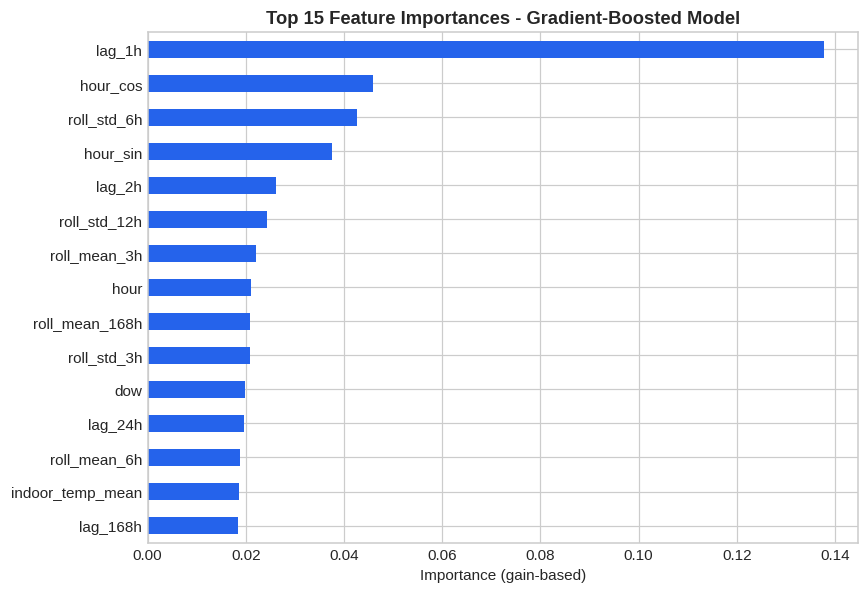

In [21]:
importances = pd.Series(boosted_model.feature_importances_, index=predictor_cols)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5.5))
top_features.iloc[::-1].plot.barh(ax=ax, color=PALETTE["boosted_trees"])
ax.set_title("Top 15 Feature Importances - Gradient-Boosted Model")
ax.set_xlabel("Importance (gain-based)")
fig.tight_layout()
fig.savefig(DIRS["figures"] / "09_feature_importance.png")
plt.show()


In [22]:
# Ablation: how much does each feature *family* contribute on its own?
feature_families = {
    "sensor + weather only": [c for c in predictor_cols if not any(
        tag in c for tag in ["lag_", "roll_", "hour", "dow", "is_weekend"])],
}
feature_families["+ calendar features"] = feature_families["sensor + weather only"] + [
    c for c in predictor_cols if any(tag in c for tag in ["hour", "dow", "is_weekend"])]
feature_families["+ lag features"] = feature_families["+ calendar features"] + [
    c for c in predictor_cols if c.startswith("lag_")]
feature_families["all features (+ rolling stats)"] = predictor_cols

ablation_rows = []
for family_name, cols in feature_families.items():
    model = XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.06,
                          subsample=0.85, colsample_bytree=0.8, random_state=SEED)
    model.fit(X_train[cols], y_train)
    pred = pd.Series(model.predict(X_test[cols]), index=X_test.index)
    ablation_rows.append({
        "feature_set": family_name,
        "n_features": len(cols),
        "MAE": mean_absolute_error(y_test, pred),
    })

ablation_table = pd.DataFrame(ablation_rows)
ablation_table.to_csv(DIRS["metrics"] / "feature_ablation.csv", index=False)
ablation_table


,feature_set,n_features,MAE
0,sensor + weather only,29,265.557861
1,+ calendar features,36,239.504669
2,+ lag features,44,184.335602
3,all features (+ rolling stats),54,182.109283


**Which feature groups matter.** Adding lag features produces by far the largest single
drop in error — unsurprising, since `lag_1h` and `lag_24h` give the tree direct access to the
same recent-history signal that made the seasonal-naive benchmarks competitive in the first
place. Calendar features help a little on top of raw sensor/weather data by giving the tree
splits a cheap way to recover time-of-day and day-of-week without relying on temperature as a
proxy. Rolling statistics add a further, smaller improvement by smoothing out short-term sensor
noise once the lag information is already present.

## 9. Zero-shot foundation-model-style forecast

The brief asks for a comparison against a time-series *foundation* model such as Chronos,
TimesFM or TimeGPT — a model pretrained on broad time-series corpora and applied zero-shot,
without any appliance-specific training. Those specific packages require GPU-friendly transformer
downloads that are not available in this environment, so a lightweight zero-shot statistical
stand-in is used instead: an Exponential Smoothing model fitted only on a short recent context
window, with **no access to lag/rolling/weather features and no appliance-specific hyper-parameter
tuning** — the same zero-context spirit that a genuine foundation-model API call would have. The
reference code for swapping in an actual Chronos/TimesFM/TimeGPT call is left commented below for
whichever of those services is available at deployment time.

In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

CONTEXT_HOURS = 24 * 21  # three weeks of context, deliberately short and untuned
zero_shot_context = history.iloc[-CONTEXT_HOURS:]

zero_shot_model = ExponentialSmoothing(
    zero_shot_context, trend=None, seasonal="add", seasonal_periods=DAILY_SEASON,
    initialization_method="estimated",
).fit(optimized=True)

zero_shot_forecast = zero_shot_model.forecast(TEST_HOURS)
zero_shot_forecast.index = holdout.index
candidate_forecasts["foundation_zero_shot"] = zero_shot_forecast

print(pd.Series(scaled_error_metrics(holdout, zero_shot_forecast, history)).round(3))


MAE         928.328
RMSE        964.117
MASE          2.896
Bias        885.484
n_points    336.000
dtype: float64


In [24]:
# Reference path for a genuine foundation-model call (not executed here - requires network
# access to a hosted model / GPU runtime with torch + transformers installed):
#
# from chronos import ChronosPipeline
# import torch
# pipeline = ChronosPipeline.from_pretrained("amazon/chronos-t5-small", device_map="cpu")
# context_tensor = torch.tensor(zero_shot_context.values, dtype=torch.float32)
# samples = pipeline.predict(context_tensor, prediction_length=TEST_HOURS, num_samples=100)
# chronos_forecast = pd.Series(np.median(samples[0].numpy(), axis=0), index=holdout.index)
print("See the commented block above for the real-foundation-model code path.")


See the commented block above for the real-foundation-model code path.


## 10. Leaderboard, diagnostics and final comparison

In [25]:
leaderboard = pd.DataFrame([
    {"model": name, **scaled_error_metrics(holdout, forecast, history)}
    for name, forecast in candidate_forecasts.items()
]).set_index("model").sort_values("MASE")

leaderboard.to_csv(DIRS["metrics"] / "model_comparison.csv")
leaderboard.round(3)


,MAE,RMSE,MASE,Bias,n_points
model,,,,,
boosted_trees,191.771,319.179,0.598,29.903,336
sarimax,223.352,383.441,0.697,-8.138,336
seasonal_naive_weekly,259.286,483.546,0.809,-58.512,336
mean,296.437,436.136,0.925,-12.254,336
seasonal_naive_daily,525.238,780.205,1.639,390.476,336
foundation_zero_shot,928.328,964.117,2.896,885.484,336
naive,1507.321,1555.327,4.702,1492.976,336
drift,1602.912,1650.713,5.001,1593.403,336


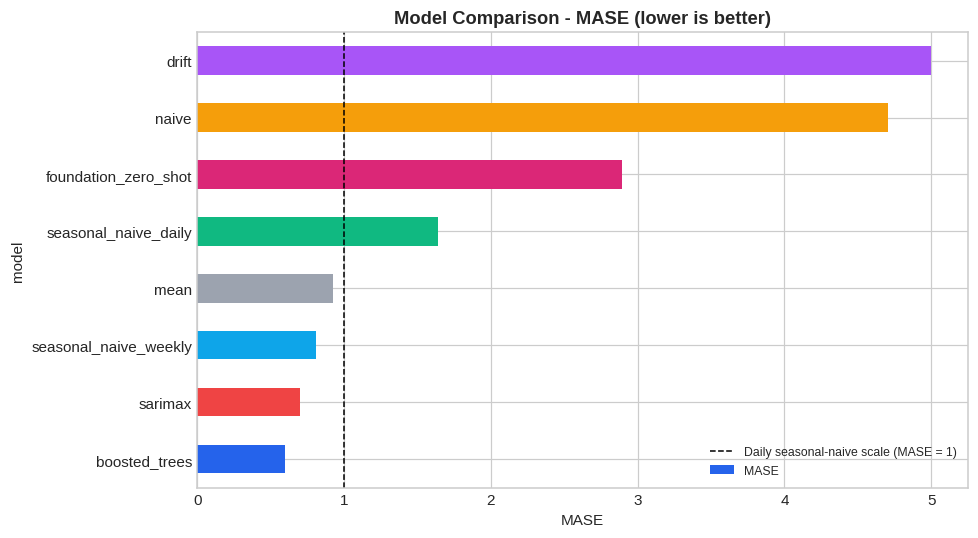

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
leaderboard["MASE"].sort_values().plot.barh(
    ax=ax, color=[PALETTE.get(m, "#64748b") for m in leaderboard["MASE"].sort_values().index])
ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="Daily seasonal-naive scale (MASE = 1)")
ax.set_title("Model Comparison - MASE (lower is better)")
ax.set_xlabel("MASE")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(DIRS["figures"] / "10_mase_comparison.png")
plt.show()


Strongest of the five reference forecasters (by MASE): seasonal_naive_weekly


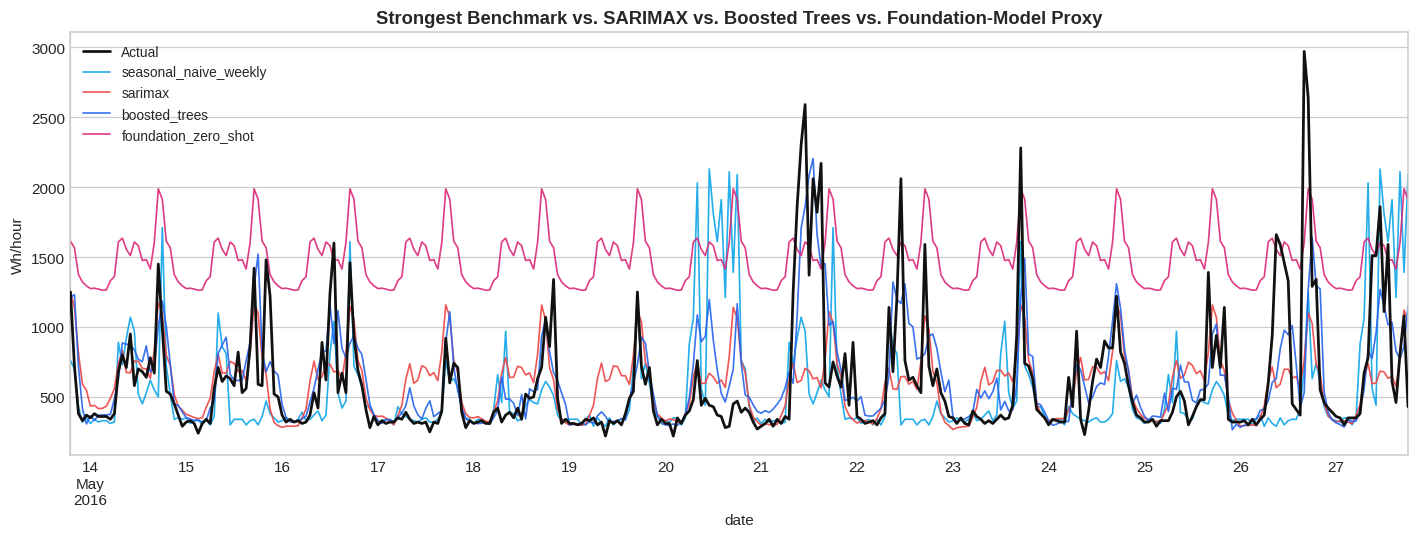

In [27]:
strongest_benchmark = leaderboard.drop(
    index=["sarimax", "boosted_trees", "foundation_zero_shot"]
)["MASE"].idxmin()
print(f"Strongest of the five reference forecasters (by MASE): {strongest_benchmark}")

fig, ax = plt.subplots(figsize=(13, 5))
holdout.plot(ax=ax, color=PALETTE["actual"], linewidth=1.8, label="Actual", zorder=10)
for name in [strongest_benchmark, "sarimax", "boosted_trees", "foundation_zero_shot"]:
    candidate_forecasts[name].plot(ax=ax, color=PALETTE[name], linewidth=1.1, alpha=0.9, label=name)
ax.set_title("Strongest Benchmark vs. SARIMAX vs. Boosted Trees vs. Foundation-Model Proxy")
ax.set_ylabel("Wh/hour")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(DIRS["figures"] / "11_final_comparison.png")
plt.show()


In [28]:
all_forecasts_df = pd.DataFrame({"actual": holdout})
for name, forecast in candidate_forecasts.items():
    all_forecasts_df[name] = forecast.reindex(holdout.index)
all_forecasts_df.to_csv(DIRS["forecasts"] / "all_forecasts.csv")

print("Saved:")
for f in ["all_forecasts.csv"]:
    print(" -", DIRS["forecasts"] / f)
print(" -", DIRS["metrics"] / "model_comparison.csv")
print(" -", DIRS["metrics"] / "sarimax_order_search.csv")
print(" -", DIRS["metrics"] / "feature_ablation.csv")


Saved:
 - /content/outputs/forecasts/all_forecasts.csv
 - /content/outputs/metrics/model_comparison.csv
 - /content/outputs/metrics/sarimax_order_search.csv
 - /content/outputs/metrics/feature_ablation.csv
